---
title: "PGC v1.5 / v1.6 shrinked noise covariance"
author: "Saikat Banerjee"
format:
  html: default
date: "2026-06-12"
file-modified: "2026-06-12"
abstract: "This adds shrinked noise covariance to the versioned PGC input files used by the Clorinn v2 pipeline."
---

In [1]:
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from pymir import mpl_stylesheet
from pymir import mpl_utils
mpl_stylesheet.banskt_presentation(splinecolor='black', dpi=300, colors='kelly')
from matplotlib import colormaps as mpl_cmaps
import matplotlib.colors as mpl_colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

## Configuration and input files

The input files are taken from v1.1 and v1.2. 
[Click here to view the v1.1 and v1.2 data processing notebook](./2026-04-30-data-preprocessing-v1-1.ipynb).

The output files are versioned using `outsuffix = "v1_5" / "v1_6"` and written to `pgc_v1.5/` and `pgc_v1.6/`.

In [28]:
datadir = "/gpfs/commons/groups/knowles_lab/data/PsychGen/input"
inputdir    = Path(datadir) / "pgc_v1.3"
inputsuffix = "v1_3"
outdir      = Path(datadir) / "pgc_v1.5"
outsuffix   = "v1_5"

# Input files
zscore_file    = Path(inputdir) / f"zscore_{inputsuffix}.csv"
noise_cov_file = Path(inputdir) / f"sampling_covariance_{inputsuffix}.csv"
category_file  = Path(inputdir) / f"trait_to_group_{inputsuffix}.json"

# Output files
def ensure_parent(path):
    Path(path).parent.mkdir(parents=True, exist_ok=True)


shrinked_noise_cov_outfile = Path(outdir) / f"shrinked_noise_covariance_{outsuffix}.csv"
ensure_parent(shrinked_noise_cov_outfile)

# Read files
def load_zscore(zscore_path):
    df = pd.read_csv(Path(zscore_path), header=0, index_col=0, dtype={0: str})
    df.index = df.index.map(str)
    df.columns = df.columns.map(str)
    return df

Z_df = load_zscore(zscore_file)
A_df = pd.read_csv(noise_cov_file, header = 0, index_col=0)
with open(category_file, "r") as f:
    trait_to_group = json.load(f)

## Load intercept SE from LDSC results

In [29]:
def normalize_trait_name(name):
    rename_map = {
        "Saxena": "Daytime_sleepiness",
    }
    if not isinstance(name, str):
        return name
    name = name.replace("-", "_")
    name = rename_map.get(name, name)
    return str(name)
    

def get_matrix_df_from_json(fpath, check_sanity=True):
    with open(Path(fpath), "r") as f:
        d = json.load(f)
    rows = []
    traits = []
    for a_vs_b, val in d.items():
        trait_a, trait_b = ([normalize_trait_name(x) for x in a_vs_b.split("_vs_")])
        traits.append(trait_a)
        traits.append(trait_b)
        rows.append({
            "trait_a": trait_a,
            "trait_b": trait_b,
            "rg": val,
        })
    traits = sorted(list(set(traits)))
    df = pd.DataFrame(rows)

    n = len(traits)
    R = pd.DataFrame(np.nan, index=traits, columns=traits, dtype=float)
    R.values[R.index.get_indexer(df["trait_a"]),
             R.columns.get_indexer(df["trait_b"])] = df["rg"].to_numpy()
    R.values[R.index.get_indexer(df["trait_b"]),
             R.columns.get_indexer(df["trait_a"])] = df["rg"].to_numpy()

    if check_sanity:
        # Max and min values
        print(f"max={R.max().max():.3g}, min={R.min().min():.3g}")
        # Symmetry sanity (in case the input accidentally contains BOTH directions)
        asym = np.nanmax(np.abs(R.values - R.values.T))
        print(f"max |R - R.T| = {asym:.3g}")   # expect 0.0 if each pair listed once
        
        # Coverage: how many off-diagonal pairs are actually populated?
        off = ~np.eye(len(traits), dtype=bool)
        print(f"populated off-diagonal fraction: {np.isfinite(R.values[off]).mean():.3f}")
        
    return R

A_se_df = get_matrix_df_from_json(Path(datadir) / "ldsc_results/gcov_int_se.txt")

max=0.0872, min=0.00397
max |R - R.T| = 0
populated off-diagonal fraction: 0.951


## Shrink the noise covariance

Here, we follow the same method as in GLEANR:
- Blockify
- Strimmer shrinkage

In [44]:
from clorinn.utils.covariance_shrinkage import shrink_covariance

A_shrinked_df, info = shrink_covariance(
    A_df,
    A_se_df,
    block_covar=0.2,
    use_correlation_scale=True,
    return_info=True,
)

info

{'gamma': 0.00011848241155755767,
 'numerator': 0.040765216089706936,
 'denominator': 344.06132989539606,
 'n_pairs_used': 378,
 'use_correlation_scale': True,
 'block_covar': 0.2,
 'n_blocks': 12,
 'block_sizes': [27, 3, 2, 4, 2, 2, 2, 2, 2, 2, 5, 2],
 'input_diag_min': 0.9876,
 'input_diag_max': 1.0607}

## How different is the shrinked noise covariance?

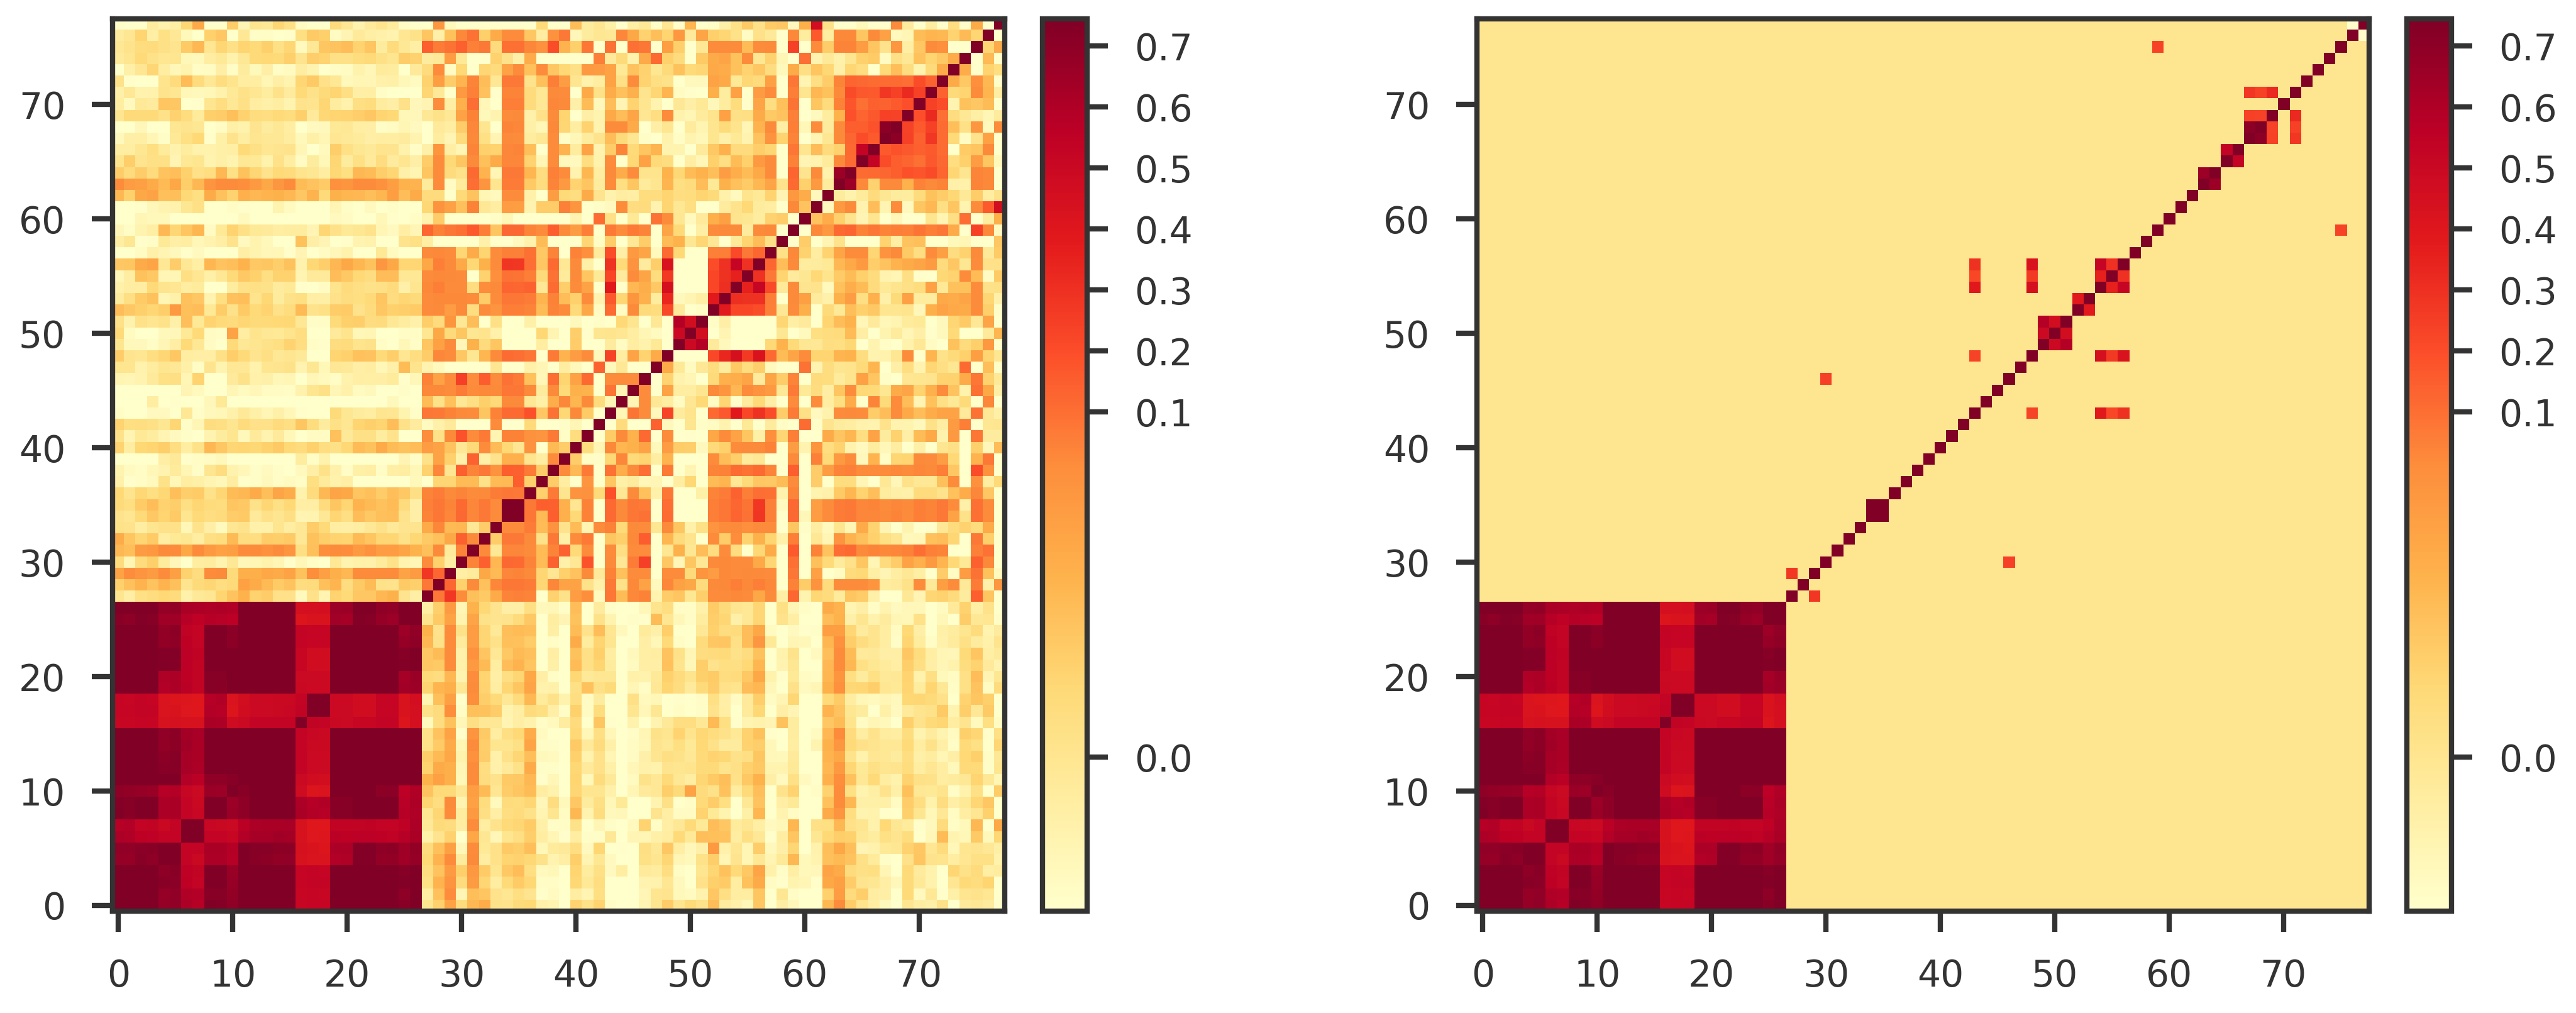

In [45]:
def make_heatmap_figure(A, B):
    
    def get_mpl_norm(X):
        X = np.asarray(X)
        offdiag = ~np.eye(X.shape[0], X.shape[1], dtype=bool)
        ok = np.isfinite(X) & offdiag
        vmin = np.quantile(X[ok], 0.1)
        vmax = np.quantile(X[ok], 0.95)
        # vmax = np.max(X[ok])
        vcenter = np.quantile(X[ok], 0.75)
        if not vmin > vcenter > vmax:
            ok_nz = ok & (X != vmin)
            vcenter = np.quantile(X[ok_nz], 0.75)
            vmax = np.quantile(X[ok_nz], 0.95)
        return mpl_colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
        
    
    A = A.to_numpy()
    B = B.to_numpy()
    
    fig = plt.figure(figsize = (16,8))
    gs  = fig.add_gridspec(nrows=1, ncols=2, wspace=0.4, hspace=0)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])

    cmap1 = mpl_cmaps.get_cmap("YlOrRd").copy()

    im1 = ax1.imshow(A, cmap=cmap1, norm=get_mpl_norm(A), origin='lower')
    divider = make_axes_locatable(ax1)
    cax = divider.append_axes("right", size="5%", pad=0.2)
    cbar = plt.colorbar(im1, cax=cax, fraction=0.1)

    im2 = ax2.imshow(B, cmap=cmap1, norm=get_mpl_norm(A), origin='lower')
    divider = make_axes_locatable(ax2)
    cax = divider.append_axes("right", size="5%", pad=0.2)
    cbar = plt.colorbar(im2, cax=cax, fraction=0.1)

    plt.show()
    
make_heatmap_figure(A_df, A_shrinked_df)

## Validate sampling covariance

The sampling covariance must be numerically well behaved for the correlated-noise Clorinn objective.

We check for symmetry and positive definiteness.

A symmetric positive-definite covariance is required for stable likelihood evaluation, inversion, and missingness-pattern-specific covariance operations downstream.

In [46]:
tol = 1e-8
A = A_shrinked_df.to_numpy()
is_symmetric = np.allclose(A, A.T, atol=tol, rtol=0)
if is_symmetric:
    print("This matrix is symmetric.")
else:
    print("This matrix is not symmetric.")
    max_asymmetry = np.abs(A - A.T).max()
    print("max_asymmetry:", max_asymmetry)

eigvals = np.linalg.eigvalsh((A + A.T) / 2)
is_pd = np.all(eigvals > 0)

if is_pd:
    print ("This matrix is PD.")
else:
    print ("This matrix is not PD.")
    print (f"Minimum eigenvalue: {eigvals.min():g}")
    print ("Zero / Negative eigenvalues:")
    print(eigvals[eigvals <= 0])


This matrix is symmetric.
This matrix is PD.


## Write release files

The only new release files are `shielded_noise_covariance_v1_3.csv` 
and `shielded_noise_covariance_v1_4.csv`.

Other input files are copied from v1.1 and v1.2 respectively.

In [27]:
# A_shrinked_df.to_csv(shrinked_noise_cov_outfile)